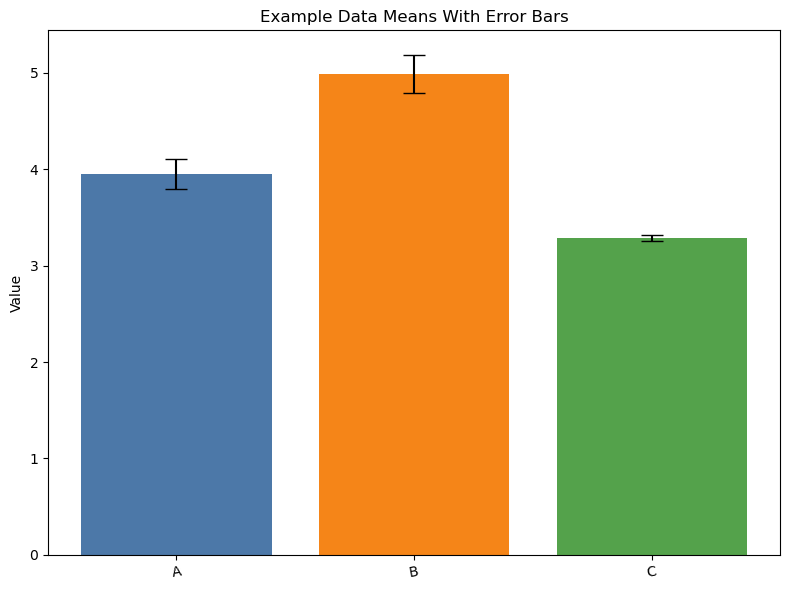

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

array_1 = rng.normal(loc=4.0, scale=1.0, size=100)
array_2 = rng.normal(loc=5.0, scale=1.0, size=100)
array_3 = 3.0 + rng.beta(a=2.0, b=5.0, size=100)

data = [array_1, array_2, array_3]
labels = ["A", "B", "C"]
means = [values.mean() for values in data]
stds = [stats.sem(values)*1.98 for values in data]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(labels, means, yerr=stds, capsize=8, color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_ylabel("Value")
ax.set_title("Example Data Means With Error Bars")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

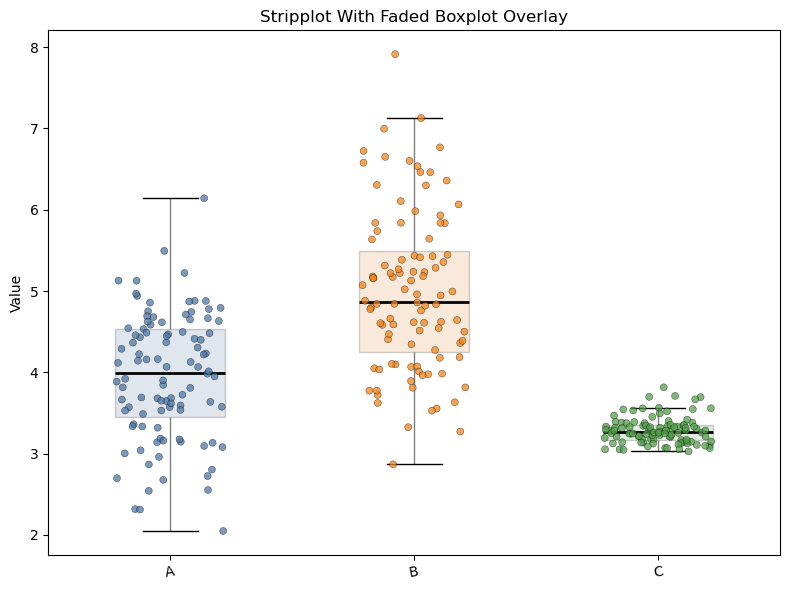

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

palette = ["#4C78A8", "#F58518", "#54A24B"]

df = pd.DataFrame(
    {
        "group": np.repeat(labels, [len(array_1), len(array_2), len(array_3)]),
        "value": np.concatenate([array_1, array_2, array_3]),
    }
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="group",
    y="value",
    hue="group",
    dodge=False,
    width=0.45,
    showcaps=True,
    palette=palette,
    boxprops={"alpha": 0.18, "edgecolor": "black"},
    whiskerprops={"alpha": 0.5},
    medianprops={"color": "black", "linewidth": 2},
    flierprops={"marker": "", "markersize": 0},
    ax=ax,
    zorder=1,
    legend=False,
    linecolor="black",
)

sns.stripplot(
    data=df,
    x="group",
    y="value",
    hue="group",
    dodge=False,
    jitter=0.22,
    size=5,
    alpha=0.75,
    palette=palette,
    ax=ax,
    zorder=2,
    linewidth=0.3,
    edgecolor="black",
    legend=False,
)

ax.set_title("Stripplot With Faded Boxplot Overlay")
ax.set_xlabel("")
ax.set_ylabel("Value")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

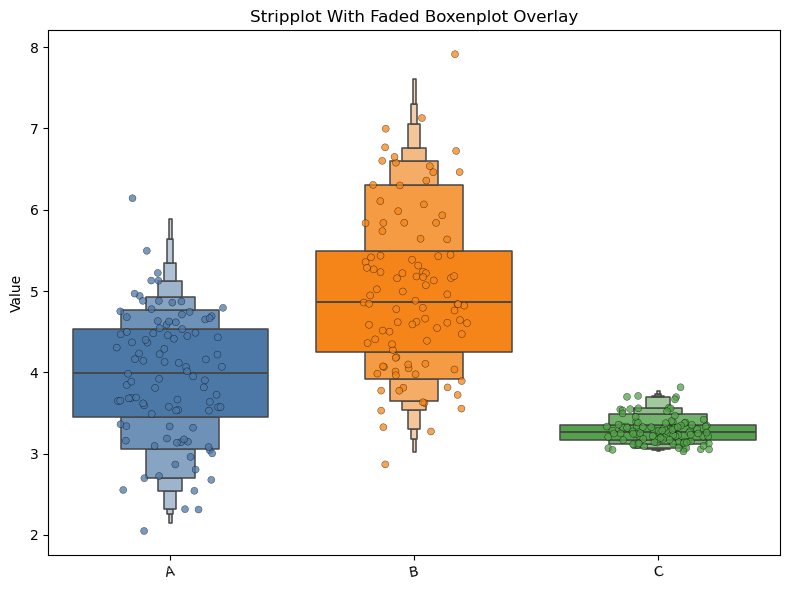

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

palette = ["#4C78A8", "#F58518", "#54A24B"]

df = pd.DataFrame(
    {
        "group": np.repeat(labels, [len(array_1), len(array_2), len(array_3)]),
        "value": np.concatenate([array_1, array_2, array_3]),
    }
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxenplot(
    data=df,
    x="group",
    y="value",
    hue="group",
    dodge=False,
    palette=palette,
    linewidth=1.1,
    saturation=1,
    k_depth="proportion",
    showfliers=False,
    ax=ax,
    zorder=1,
    legend=False,
)

for patch in ax.patches:
    patch.set_alpha(0.18)
    patch.set_edgecolor("black")

sns.stripplot(
    data=df,
    x="group",
    y="value",
    hue="group",
    dodge=False,
    jitter=0.22,
    size=5,
    alpha=0.75,
    palette=palette,
    ax=ax,
    zorder=2,
    linewidth=0.3,
    edgecolor="black",
    legend=False,
)

ax.set_title("Stripplot With Faded Boxenplot Overlay")
ax.set_xlabel("")
ax.set_ylabel("Value")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

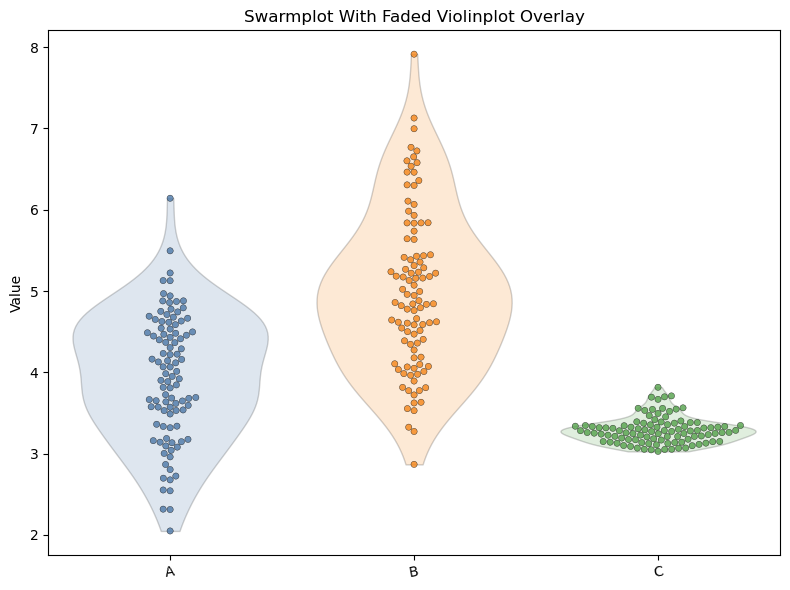

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

palette = ["#4C78A8", "#F58518", "#54A24B"]

df = pd.DataFrame(
    {
        "group": np.repeat(labels, [len(array_1), len(array_2), len(array_3)]),
        "value": np.concatenate([array_1, array_2, array_3]),
    }
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.violinplot(
    data=df,
    x="group",
    y="value",
    hue="group",
    dodge=False,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=1.0,
    saturation=1,
    ax=ax,
    zorder=1,
    legend=False,
)

for collection in ax.collections:
    try:
        collection.set_alpha(0.18)
        collection.set_edgecolor("black")
    except Exception:
        pass

sns.swarmplot(
    data=df,
    x="group",
    y="value",
    hue="group",
    dodge=False,
    size=4.5,
    alpha=0.8,
    palette=palette,
    ax=ax,
    zorder=2,
    linewidth=0.3,
    edgecolor="black",
    legend=False,
)

ax.set_title("Swarmplot With Faded Violinplot Overlay")
ax.set_xlabel("")
ax.set_ylabel("Value")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

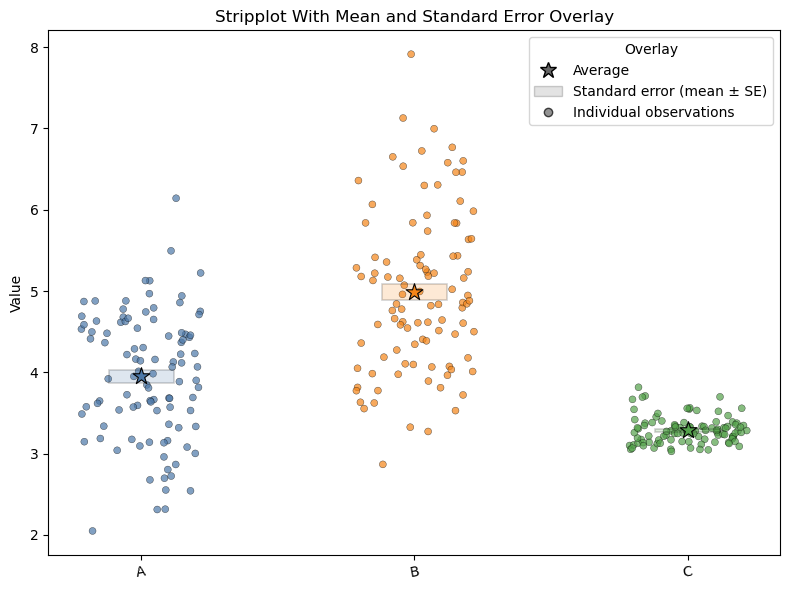

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

palette = ["#4C78A8", "#F58518", "#54A24B"]

df = pd.DataFrame(
    {
        "group": np.repeat(labels, [len(array_1), len(array_2), len(array_3)]),
        "value": np.concatenate([array_1, array_2, array_3]),
    }
)

summary = df.groupby("group", sort=False)["value"].agg(["mean", "std", "count"]).reset_index()
summary["se"] = summary["std"] / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(8, 6))

sns.stripplot(
    data=df,
    x="group",
    y="value",
    hue="group",
    dodge=False,
    jitter=0.22,
    size=5,
    alpha=0.7,
    palette=palette,
    ax=ax,
    linewidth=0.3,
    edgecolor="black",
    legend=False,
)

x_positions = ax.get_xticks()
square_width = 0.24

for x_pos, (_, row), color in zip(x_positions, summary.iterrows(), palette):
    se_box = Rectangle(
        (x_pos - square_width / 2, row["mean"] - row["se"]),
        square_width,
        2 * row["se"],
        facecolor=color,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.18,
        zorder=3,
    )
    ax.add_patch(se_box)
    ax.scatter(
        x_pos,
        row["mean"],
        s=160,
        marker="*",
        color=color,
        edgecolor="black",
        linewidth=0.8,
        zorder=4,
    )

legend_handles = [
    Line2D(
        [0], [0],
        marker="*",
        color="none",
        markerfacecolor="#666666",
        markeredgecolor="black",
        markersize=12,
        label="Average",
    ),
    Patch(
        facecolor="#666666",
        edgecolor="black",
        alpha=0.18,
        label="Standard error (mean ± SE)",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="#666666",
        markeredgecolor="black",
        alpha=0.7,
        markersize=6,
        label="Individual observations",
    ),
]

ax.legend(handles=legend_handles, title="Overlay", frameon=True)
ax.set_title("Stripplot With Mean and Standard Error Overlay")
ax.set_xlabel("")
ax.set_ylabel("Value")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()